# ERP analysis using MNE

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Get familiar with dynamic stopping in BCI applications;
- Get familiar with the MNE toolbox for EEG analysis;
- Get familiar with sklearn for EEG decoding;
- Get familiar with an online experiment setting;
- Get familiar with possible ethical discussions to be had about BCI.

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


## Top-down view onto this notebook

##### Dynamic stopping (programming)
1. You will answer a few theoretical questions
1. You will look at ERP data collected from an experiment that looks a lot like the AMUSE paradigm ([video showing the AMUSE paradigm
](https://youtu.be/l2V5pMdYYfA?t=123)). But, instead of tones we present 6 monosyllabic words played on the 6 speakers surrounding the subject.
1. You will implement a dynamic stopping procedure in a simulated online experiment.
    
##### Ethics (presentation/discussion)
1. You will dive into the ethics of an aspect of BCI you're interested in (we'll give you a few starting points) 
1. You will introduce your peers to your chosen topic by creating and posting *one* of the following:
    * an informational video 
    * a **short** report/summary document
    * a video/written summary of a discussion that you had amongst your teammates
    * any other medium you want to use! 🥳

# Dyanmic Stopping

## Exercise 1: Time-accuracy trade-off

In online (ERP) BCI usage we have to deal with a trade-off between selection accuracy and selection speed.
1. Explain what is meant with the trade-off between selection accuracy and speed, and how we can find a sweet spot in this trade-off during online use.
1. Explain how Höhne's dynamic stopping methods works. More specifically, try to explain the method by splitting it in simple steps.
1. What are some of the pro(s) and con(s) of this method?
1. How does this method compare to the other methods mentioned in the lecture (Fixed & Liu)?

#### Answer here
1. 

2. 

3. 

4. 

## Exercise 2: Import, preprocess and inspect the data

#### Experimental setup:
In every trial the patient/user (from now on 'participant') has to focus on a single word from the set of 6 words. Each word/stimulus is played once per iteration. This means that an iteration consists of 6 words/stimuli, of which one is the target word. A sequence of 15 iterations, adding up to 90 stimuli, form one complete trial. The goal of a single trial is to determine what the target word is. This means that each iteration in a single trial shares the same target word. However, the order in which words are presented between iterations in a single trial may differ. To summarise, each trial has a single target word. Each trial consists of 15 iterations in which all 6 words are played once.

#### General EEG data information:
The data provided contains three file types: `.vhdr`, `.vmrk`, `.eeg`.  In the each `.vhdr` file you will find information about all recorded channels. Five of the channels listed are non-EEG channels:
* The EMG channel records an electromyogram. This is muscle activity.
* The GSR channel records the galvanic skin response. This is sweat gland activity which is indicative of stress levels and excitation.
* The Respi channel records respiration activity.
* The Pulse channel records the heart pulses by shining a red light on the finger and recording how much of it is reflected back.
* The Optic channel is an optical sensor focused on a portion of the screen that flashes every time an event happens in order to detect potential interference/delay between the time point the computer issues a stimulus and the time the stimulus is actually presented on the screen to the user.

Some of these channels can be used to remove artefacts from the EEG signal and better phase-locking the signals. For our experiment though they aren't relevant.

In the `.vhdr` files you will also find the resolution ( $\mu V$ steps) of each channel and the impedance (kOhm) of all channels, a higher impedance results in a higher noise level.

In each `.vmrk` you will find the event marker information. Each stimulus/event has an `event_id`. In our case, non-target words have event_ids $[101, 102, ..., 106]$. We have 6 different words. In every trial exactly 1 of them is in the target role. The target words are indicated by $[111,112, ..., 116]$. So, the last digit indicates the word id, the second digit indicates whether a stimulus is a target $(1)$ or non-target $(0)$.

Lastly, each `.eeg` file contains the recorded signals encoded in binary values and stored as integers. Increasing the value by 1 corresponds to a step value of 0.1 $\mu V$, which is the resolution denoted in the header (`.vhdr`) file.

Your task now is to:

1. Get the ERP data from Brightspace.
2. (Optional) Inspect a single `.vhdr` and `.vmrk` file. You can open them with a text editor such as Notepad (or even VS code). Check where in the file the sampling resolution of the EEG channels is given. Has the frequency range been limited? If so, to what band? What is the sampling rate? Can you guess what was the intended temporal difference between 2 successive stimulus onsets? What could be the reason for this difference not being constant?

Answer: Sampling resolution (smallest change in voltage that can be detected) is given in the [Channel Infos] in format <Resolution in "Unit">. The frequency range has been limited from 0-250 Hz and the sampling rate is 1000 Hz. The intented time difference between 2 onsets is approximately 250 ms and the variation can be caused due to the hardware jitter and system timing. 

3. (Optional) Inspect the preprocessing functions we've provided and write down a short description of what each function does at every step. If you're unsure about some functions, look up the documentation of the relevant library.
    * In the creation of epochs, we decimate the sampling rate. Would this cause an aliasing problem? Why or why not?

Answer: No there is no aliasing problem since they original sampling rate is 1000 Hz and after decimation it is 100 Hz. Nyquist frequency then is 50 Hz and the high cutoff  in the preprocessing filtering is 16 Hz so there is no problem.
 
4. Plot the average ERP response of a word of your choice for when it is the target condition vs. the non-target condition. Can you spot the difference in average response when a target vs. non-target stimulus is presented? Describe this in terms of amplitudes, inter-channel variance and delay of EEG components. See: [MNE Epoch documentation](https://mne.tools/stable/generated/mne.Epochs.html) and [MNE Evoked documentation](https://mne.tools/stable/generated/mne.Evoked.html).

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import sklearn.metrics as metrics
import scipy as sp
import scipy.stats as stats
import warnings

warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')

np.random.seed(42)

In [2]:
# Preparations

def load_and_preprocess_raw(header_file, filter_band=(0.5, 16)):
    non_eeg_channels = ["EOGvu", "x_EMGl", "x_GSR", "x_Respi", "x_Pulse", "x_Optic"]
    raw = mne.io.read_raw_brainvision(header_file, misc=non_eeg_channels, preload=True)
    raw.set_montage("standard_1020")
    raw.filter(*filter_band, method="iir")
    raw.pick_types(eeg=True)
    return raw

def epoch_raw(raw, decimate=10):
    target_ids = list(range(111, 117))
    non_target_ids = list(range(101, 107))
    event_id = {f"Word_{i-110}/Target": i for i in target_ids}
    event_id.update({f"Word_{i-100}/NonTarget": i for i in non_target_ids})
    evs = mne.events_from_annotations(raw)[0]
    epoch = mne.Epochs(raw, events=evs, event_id=event_id, decim=decimate,
                       proj=False, tmax=1)
    return epoch

# Get the data path
data_dir = Path.cwd() / "data" 
header_files = data_dir.glob("auditoryAphasia*.vhdr")

# Load the data, preprocess and slice it into epochs
epochs = list()
for f in header_files:
    raw_data = load_and_preprocess_raw(f)
    epochs.append(epoch_raw(raw_data))

# Overwrite epochs list to save memory
epochs = mne.concatenate_epochs(epochs)

# Combine 6 epochs into a single iteration (6 stimuli together form a single iteration)
iterations = [epochs[i:i+6] for i in np.arange(0, epochs.events.shape[0],6)]  # 3240 like len(epochs)

# Assert that each iteration contains exactly 1 Target
assert all([len(iteration["Target"]) == 1 for iteration in iterations]), "Number of targets in single iterations is unequal to 1."

# 15 iterations form a single trial
trials = [iterations[i:i+15] for i in np.arange(0,len(iterations),15)]

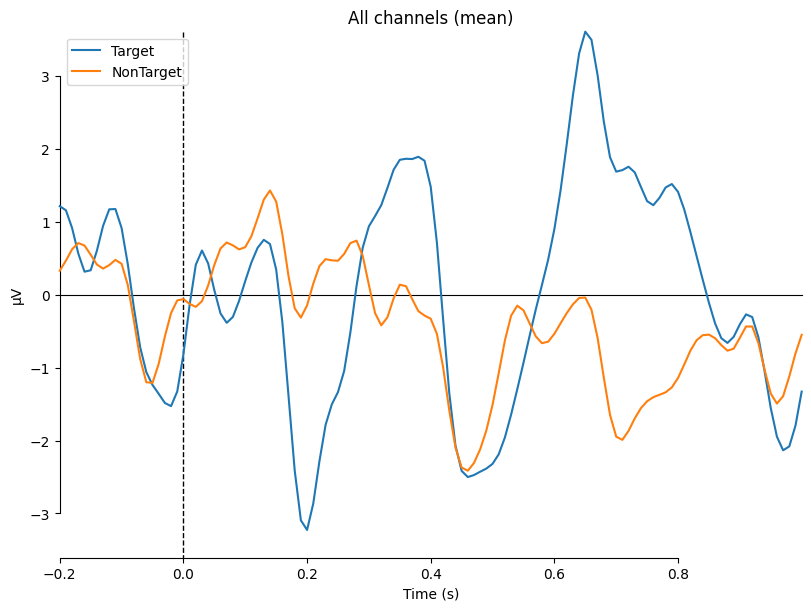

C:\Users\ptrso\AppData\Local\Temp\ipykernel_12448\1579637356.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


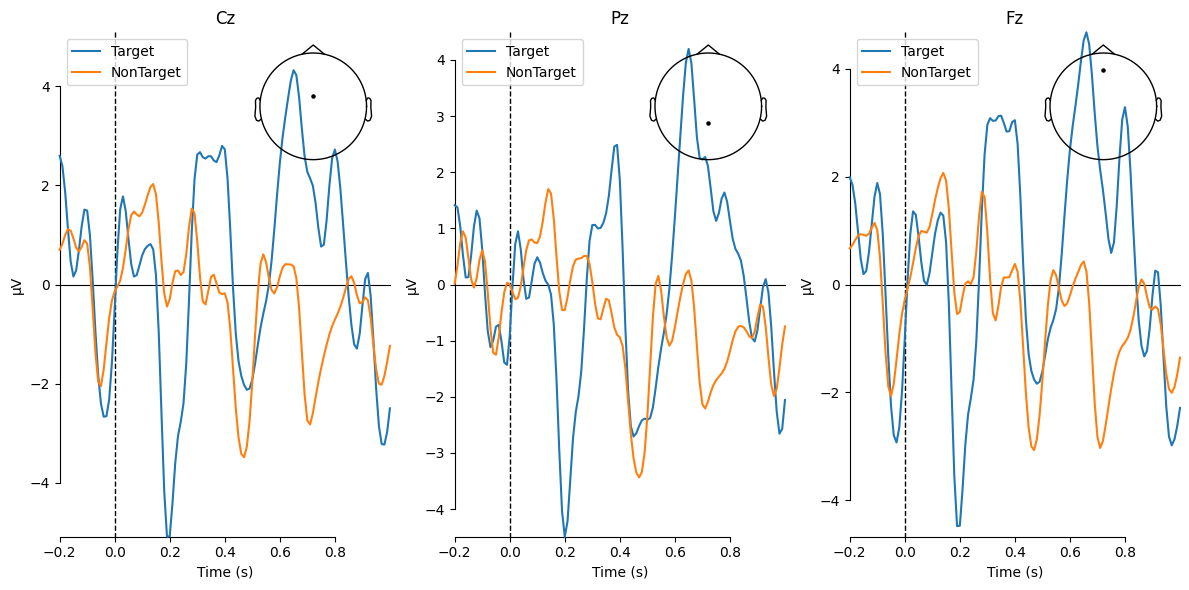

C:\Users\ptrso\AppData\Local\Temp\ipykernel_12448\1579637356.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


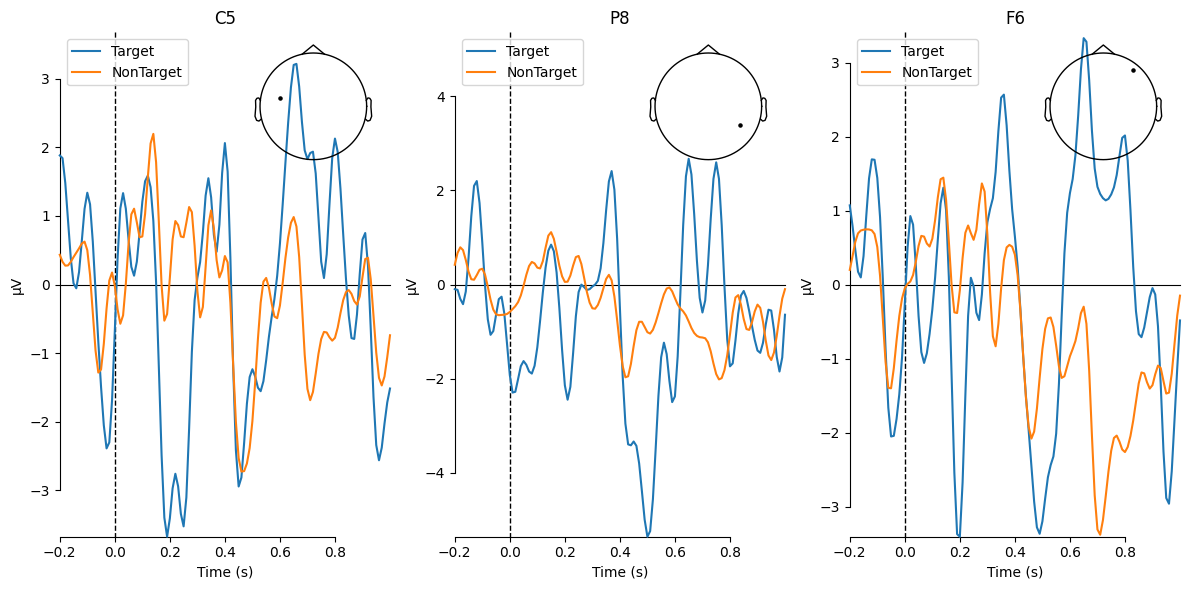

In [3]:
# Answer here

# print(len(epochs))
# epochs.plot()  # all of the epochs all channels 
targ1 = epochs["Word_1/Target"].average()
non_targ1 = epochs["Word_1/NonTarget"].average()
# targ1.plot_joint()
# non_targ1.plot_joint()

good_channels = ['Cz','Pz','Fz']
bad_channels = ['C5', 'P8', 'F6']

mne.viz.plot_compare_evokeds(
    {'Target': targ1, 'NonTarget': non_targ1}, combine='mean', title = 'All channels')

fig, axes = plt.subplots(1, len(good_channels), figsize=(12, 6))

for ax, ch in zip(axes, good_channels):
    mne.viz.plot_compare_evokeds(
        {'Target': targ1, 'NonTarget': non_targ1},
        picks=ch,
        combine='mean',
        axes=ax,
        show=False
    )
    ax.set_title(ch)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(good_channels), figsize=(12, 6))
for ax, ch in zip(axes, bad_channels):
    mne.viz.plot_compare_evokeds(
        {'Target': targ1, 'NonTarget': non_targ1},
        picks=ch,
        combine='mean',
        axes=ax,
        show=False
    )
    ax.set_title(ch)

plt.tight_layout()
plt.show()

On timepoints around 0.4 seconds and 0.6 sec the potential amplitude is much higher for the word heard when it is a target (>3 μV for the 3 central channels, but peaks in general for all channels) compared to when it is not. This is a characterestic of the P300 effect: stronger positive potential following attended/target stimuli. We can see that for other channels away from the midline the variance is higher. here are more identified peaks and less overall amplitude on the highest ones that are observed similarly in the 3 main channels. The delay before the major peak appears around ~0.45–0.55 s post-stimulus for **Target**,
while **NonTarget** peaks earlier (~0.2–0.3 s) and sometime there is not delay at all.

## Exercise 3: Calibration
We were able to train a decent LDA classifier on calibration data consisting of only 12 trials. The classifier is trained on individual stimuli and classifies non-targets vs targets. Remember from the previous (last week's) *assignment*: neighbouring time samples probably contain very similar information. We want to save some computing time and thus, we use a common feature preprocessing step for ERP: we average each signal in certain time intervals, which are defined by `clf_ival_boundaries`. We can average, e.g., the time samples of channel Cz between 0.1 and 0.2 seconds post stimulus presentation and this will yield 1 feature dimension to the final feature space. In the example below we use 4 time intervals per channel resulting in a feature dimensionality of $63_{\text{channels}} \cdot 4_{\text{averaged time intervals}} = 252$ features.

1. Inspect the shapes of `calibration_trials` and `calibration_stimuli`, what does every dimension mean? Why do we reshape the data?

1. Inspect how the classifier is trained and validated. Would it be a good idea to shuffle the data prior to making this training/validation split to get an even better performance?

1. Can you find certain time intervals for `clf_ival_boundaries` that lead to better classification performance? Hint: look at the plots from the previous *exercise*.

c:\Users\ptrso\.conda\envs\bci-course\lib\site-packages\sklearn\metrics\_plot\roc_curve.py:171: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


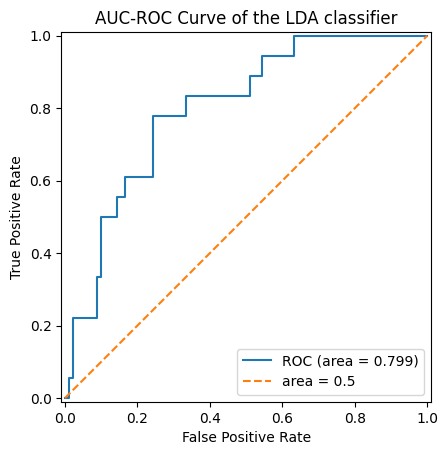

In [4]:
def get_jumping_means(epo, boundaries):
    shape_orig = epo.get_data().shape
    X = np.zeros((shape_orig[0], shape_orig[1], len(boundaries)-1))
    for i in range(len(boundaries)-1):
        idx = epo.time_as_index((boundaries[i], boundaries[i+1]))
        idx_range = list(range(idx[0], idx[1]))
        X[:,:,i] = epo.get_data()[:,:,idx_range].mean(axis=2)
    return X

# Split trials into calibration set and online set
raw_calibration_trials = trials[0:12] # data used to simulate the calibration part of the experiment.
online_trials = trials[12:] # data used to simulate the online experiment.

# Specify the intervals over which to average the timepoints
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

# Extract relevant features
# iteration = list of 6 stimuli - trial = list of 15 iterations
calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])

# Reshape our data appropriately for feeding it into LDA
calibration_stimuli = np.reshape(calibration_trials, (np.prod(calibration_trials.shape[0:3]),-1)) 
calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten()

### LDA

# Train a classifier on the calibration data and verify that it can classify targets using a subset of the calibration data.
X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
clf = LDA().fit(X_train, y_train)

fpr, tpr, thresholds = metrics.roc_curve(y_test,clf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC (area = %0.3f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier")
plt.show()

In [5]:
print("Calibration trials:", len(raw_calibration_trials)) # 12, [0]=>15, [0][0]=>6
print("Online trials",len(online_trials))
print(calibration_trials.shape)
print(calibration_stimuli.shape)
print(np.array(raw_calibration_trials[0][0].events).shape)

Calibration trials: 12
Online trials 24
(12, 15, 6, 63, 4)
(1080, 252)
(6, 3)


#### Answer here
1. The calibration data contain 12 trials, each with 15 iterations of 6 stimuli, giving 12×15×6 = 1080 total stimuli. Each stimulus is represented by 63 channels × 4 averaged time intervals = 252 features. After reshaping, we obtain calibration_stimuli of shape (1080, 252) and matching labels (1080,), where each row corresponds to a single target or non-target word presentation.

2. No it is not a good idea to reshuffle here. For one, with the calibration and online trials we are trying to simulate the real EEG experiment and they also have a sequential temporal connection that would be broken. Moreover, there is a chance of overfitting as similar data in time could be used for training and testing and the classifier then giving a higher than normal performance.

3. 

## Exercise 4: Simulated online experiment and dynamic stopping
Now it's time for the simulated online experiment! 🥳 In this exercise we will implement the early stopping method that uses a statistical test (Höhne's method).

In the online setting, we want to determine the target stimulus per trial. This is typically done at the end of the trial, however, in the case of dynamic stopping this prediction is made when we have sufficient evidence for one of the classes being the target class. To properly simulate an online experiment, you would have to treat each stimulus as if it had been just recorded. Normally, this means you would have to apply all the preprocessing steps (spectral filtering, downsampling,  etc.). We already did that for you while importing the data. So, all that is left for you to do in terms of preprocessing is extracting the features by applying the time interval averaging using the `get_jumping_means()` function (as shown in the code given below). 

#### Some information about the variables:
- `online_trial_targets` contains the target word id ($[1,2, ..,6]$) per trial. These should **only** be used to quantify the performance.
- `online_labels` contains whether the presented stimulus/word is a target (1) or a non-target (0). Note that the order of stimuli differs per iteration.
- `online_words` contains the word id ($[1,2, ..,6]$) per stimulus/word presentation. 

1. Inspect the code given below. In this code the classifier predicts the signed distance to the decision boundary, given a single presented stimulus/word. You will build on top of this code, so make sure you understand the three variables listed above.

1. **Condition A: no dynamic stopping applied.** Predict (using the provided classifier `clf`) the target words per trial, using the entire trial information. In other words, keep track of the **signed distances** to the decision hyperplane per word id throughout the entire trial to make a single prediction about the target word after all 15 iterations. Report your prediction accuracy. 
**NOTE**: The order in which words are presented differs per iteration in a trial. Also note that the classifier tried to learn a decision hyperplane such that targets have a positive signed distance to the hyperplane, and non-targets have a negative signed distance to the hyperplane.

1.  **Condition B: dynamic stopping applied.** Predict (using the provided classifier `clf`) the target words per trial while using a dynamic stopping procedure (Höhne's method). Perform a [(Welch's) t-test](https://en.wikipedia.org/wiki/Welch%27s_t-test) (look for the approriate Scipy function) per iteration to see whether you can stop the trial early. Make sure to first gather at least a few iterations before you start checking whether you can stop the trial early. You can decide on the p-value and the minimum number of iterations you wish to use. 

1. Report the average accuracy and average number of iterations per trial when using the dynamic stopping procedure with this p-value. Also convert the average number of iterations per trial to the average duration of a trial in seconds (using the sampling frequency).
    
1. Visualise:
    * The trade-off between accuracy and the p-value threshold.
    * the trade-off between the average time (s) of a trial and the p-value threshold. 
    * The trade-off between accuracy and the average time (s) of a trial.

    You can visualise this by repeating 3.4 for a range of p-value threshold values. Make use of the p-value thresholds in the range of [0.001,0.5] with a sufficiently small step size to yield a somewhat smooth plot. 

    **Note:** For 3.5 you will loop over all trials in the online experiment using different values for the p_value threshold for dynamic stopping. This can take a few minutes when you have many different values for the threshold. For fun: you can have a look at using a progress bar for your loop, they are extremely easy and useful! An example is given in a code cell below.

c:\Users\ptrso\.conda\envs\bci-course\lib\site-packages\sklearn\metrics\_plot\roc_curve.py:171: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


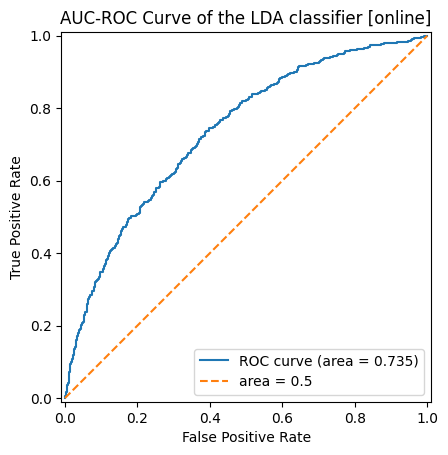

In [6]:
### This code is given and can be used in the subsequent exercises to build upon.
warnings.simplefilter("ignore", category=DeprecationWarning)

# Extract relevant data, labels and the played words
# First iteration's target event codes. The target is identical in all iterations of trial.
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.
# iteration.events[n_epochs, 0, event_codes (5: 101-106 and 1: 111-116)]

# 4.1: Predict target/non-target per stimulus.

signed_distances = np.zeros(online_words.shape)

for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            signed_distances[t,i,s] = clf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1)) # Compute signed distance of stimulus to decision boundary

fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.3f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier [online]")
plt.show()

In [7]:
# print(np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]))
print(online_trial_targets.shape)
print(online_labels.shape)
print(online_words.shape)
print(online_words[0])  # 1 trial example
print(online_labels[0][0])  # 1 iteration example
print(signed_distances[0][0])  # 1 iteration example

(24,)
(24, 15, 6)
(24, 15, 6)
[[6 3 4 2 5 1]
 [4 6 5 3 1 2]
 [4 6 3 5 1 2]
 [4 3 5 1 2 6]
 [3 2 4 1 5 6]
 [3 2 4 6 1 5]
 [4 3 6 1 5 2]
 [1 3 5 6 4 2]
 [6 5 2 1 3 4]
 [5 2 3 1 4 6]
 [2 3 6 1 5 4]
 [3 5 6 1 4 2]
 [3 6 4 1 5 2]
 [6 5 2 3 4 1]
 [3 5 2 4 6 1]]
[0 0 0 1 0 0]
[ -0.91648185   2.9238624   -4.1996797   -4.17213797  -3.77100104
 -10.15695329]


In [8]:
### [OPTIONAL]: Just for fun, you can use this function that plots the distributions of the signed distances of your candidate target class vs the candidate non-target classes.
def plot_distribution_comparison(target_distances, non_target_distances): 
    signed_distances = [target_distances, non_target_distances]
    labels = ['predicted target', 'predicted non-targets']
    
    all_distances = np.concatenate((target_distances,non_target_distances),axis=None)
    x_min = np.min(all_distances)
    x_man = np.max(all_distances)
    x_axis = np.linspace(x_min, x_man)

    for i, distances in enumerate(signed_distances):
        # Fit and plot the distribution of the probabilities for the non-target words.
        mean, var  = sp.stats.distributions.norm.fit(distances)
        distri = stats.norm.pdf(x_axis,mean,np.sqrt(var))
        plt.plot(x_axis, distri, label=labels[i])

    plt.legend()
    plt.title("Distributions of the distances to the hyperplane")
    plt.xlabel("predicted distance")
    plt.ylabel("probability density function")
    plt.show()

In [9]:
### Answer here for 4.2 (Condition A, no dynamic stopping applied)
predicted_targets = []

for t in range(len(online_trials)):  # Looping over trials
    trial_distances = signed_distances[t]  # (15, 6)
    trial_words = online_words[t]

    mean_scores = np.zeros(6)  # one per word ID

    for w_id in range(1, 7):  # words are from 1-6
        mask = trial_words == w_id  # element-wise comparsion of current word ID to trial_word
        word_scores = trial_distances[mask]
        mean_scores[w_id - 1] = word_scores.mean()  # indexing from 0
    
    predicted_word = np.argmax(mean_scores) + 1
    # print(predicted_word)
    predicted_targets.append(predicted_word)  # indices matched to word IDs

predicted_targets = np.array(predicted_targets) 
accuracy = np.mean(predicted_targets == online_trial_targets) # get accuracy True/False way1
print(f"Condition A accuracy: {accuracy:.3f}")

Condition A accuracy: 0.875


In [41]:
### Answer here for 4.3 & 4.4 (Condition B, dynamic stopping applied + reporting the average accuracy and trial duration)
from scipy import stats
import numpy as np

p_thresh = 0.05          # significance level
min_iter = 4             # minimum iterations before testing
predicted_targets_tr = []
stopped_iterations = []

for t in range(len(online_trials)):
    trial_words = online_words[t]           # (15,6)
    trial_distances = signed_distances[t]   # (15,6)
    n_iter = trial_words.shape[0] 
    stop_iter = n_iter                      # default (no early stop)
    pred_word = None

    # iterate over successive iterations
    for i in range(min_iter, n_iter + 1):
        # gather data up to iteration i
        words_so_far = trial_words[:i]
        dists_so_far = trial_distances[:i]

        # compute mean score per word
        mean_scores = [dists_so_far[words_so_far == w_id].mean()
                       for w_id in range(1, 7)]
        best_id = np.argmax(mean_scores) + 1
        best_dists = dists_so_far[words_so_far == best_id]

        # compare best word to each other word
        p_values = []
        for w_id in range(1, 7):
            if w_id == best_id:
                continue
            other_dists = dists_so_far[words_so_far == w_id]
            # Welch’s t-test
            _, p = stats.ttest_ind(best_dists, other_dists, equal_var=False)  # unequal variance
            p_values.append(p)

        # if all comparisons show significance → stop
        if any(p < p_thresh for p in p_values if not np.isnan(p)):  # if this is for all comparisons the accuracy is like condition A
            stop_iter = i
            pred_word = best_id
            break

    # if never stopped, take final best
    if pred_word is None:
        pred_word = np.argmax(mean_scores) + 1

    predicted_targets_tr.append(pred_word)
    stopped_iterations.append(stop_iter)


predicted_targets_tr = np.array(predicted_targets_tr)
accuracy_dyn = np.mean(predicted_targets_tr == online_trial_targets)  # true target for all iter: online_trial_targets
avg_iters = np.mean(stopped_iterations)

# convert iterations to seconds
# (each iteration = 6 stimuli × stimulus onset asynchrony)
stim_time_diff = 0.25   # 250 ms between stimuli onset in iteration
avg_time_s = avg_iters * 6 * stim_time_diff

print(f"Dynamic stopping accuracy: {accuracy_dyn:.3f}")
print(f"Average iterations: {avg_iters:.2f}\nAverage time: ~{avg_time_s:.1f} s ({6*stim_time_diff} per iteration)")



Dynamic stopping accuracy: 0.625
Average iterations: 4.79
Average time: ~7.2 s (1.5 per iteration)


In [11]:
### Example progress bar code, super useful and easy to use!
# You might have to run this once if you don't yet have the package:
# !pip install tqdm

import time
from tqdm.notebook import tqdm

array = np.arange(1,100,1)
for i, item in enumerate(tqdm(array)):
    time.sleep(0.02)

  0%|          | 0/99 [00:00<?, ?it/s]

In [50]:
### Answer here for 4.5 (Visualisation of the trade-offs)
p_thresholds = np.arange(0.001, 0.501, 0.001)
min_iter = 4             # minimum iterations before testing
stim_time_diff = 0.25
accuracy_thr, avg_time_thr = [], []

# Hiding it since it is the same as last cell
for p_thresh in tqdm(p_thresholds):
    predicted_targets_tr = []
    stopped_iterations = []
    
    for t in range(len(online_trials)):
        trial_words = online_words[t]           # (15,6)
        trial_distances = signed_distances[t]   # (15,6)
        n_iter = trial_words.shape[0] 
        stop_iter = n_iter                      # default (no early stop)
        pred_word = None

        # iterate over successive iterations
        for i in range(min_iter, n_iter + 1):
            # gather data up to iteration i
            words_so_far = trial_words[:i]
            dists_so_far = trial_distances[:i]

            # compute mean score per word
            mean_scores = [dists_so_far[words_so_far == w_id].mean()
                        for w_id in range(1, 7)]
            best_id = np.argmax(mean_scores) + 1
            best_dists = dists_so_far[words_so_far == best_id]

            # compare best word to each other word
            p_values = []
            for w_id in range(1, 7):
                if w_id == best_id:
                    continue
                other_dists = dists_so_far[words_so_far == w_id]
                # Welch’s t-test
                _, p = stats.ttest_ind(best_dists, other_dists, equal_var=False)  # unequal variance
                p_values.append(p)

            # if all comparisons show significance → stop
            if any(p < p_thresh for p in p_values if not np.isnan(p)):  # if this is for all comparisons the accuracy is like condition A
                stop_iter = i
                pred_word = best_id
                break

        # if never stopped, take final best
        if pred_word is None:
            pred_word = np.argmax(mean_scores) + 1

        predicted_targets_tr.append(pred_word)
        stopped_iterations.append(stop_iter)

    # For different p-value thresholds you have different accuracies and average iterations
    predicted_targets_dyn = np.array(predicted_targets_tr)
    accuracy_dyn = np.mean(predicted_targets_dyn == online_trial_targets)  # true target for all iter: online_trial_targets
    avg_iters = np.mean(stopped_iterations)

    # convert iterations to seconds
    avg_time_s = avg_iters * 6 * stim_time_diff

    accuracy_thr.append(accuracy_dyn) 
    avg_time_thr.append(avg_time_s)

  0%|          | 0/500 [00:00<?, ?it/s]

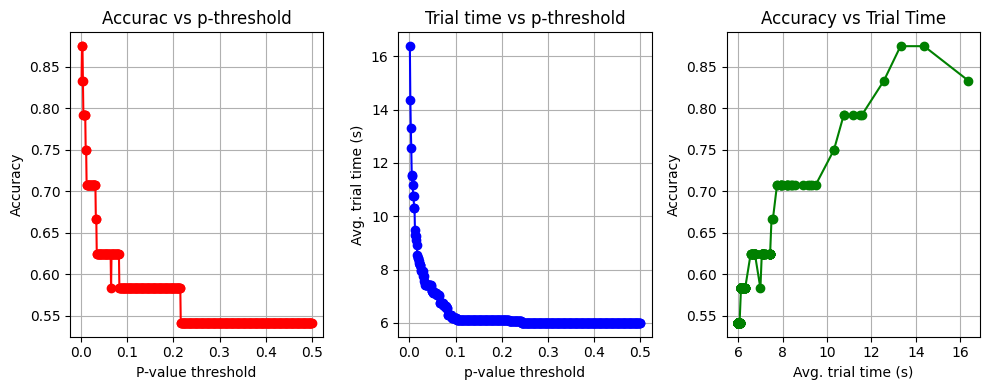

In [62]:
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.plot(p_thresholds, accuracy_thr, '-or')
plt.grid()
plt.xlabel('P-value threshold');plt.ylabel("Accuracy")
plt.title("Accurac vs p-threshold")

plt.subplot(1,3,2)
plt.plot(p_thresholds, avg_time_thr, '-ob')
plt.grid()
plt.xlabel("p-value threshold"); plt.ylabel("Avg. trial time (s)")
plt.title("Trial time vs p-threshold")

plt.subplot(1,3,3)
plt.plot(avg_time_thr, accuracy_thr,'-og')
plt.grid()
plt.xlabel("Avg. trial time (s)"); plt.ylabel("Accuracy")
plt.title("Accuracy vs Trial Time")

plt.tight_layout()
plt.show()

# Ethics


## Exercise 5: discussion about an ethics topic
In this exercise we want you to get creative.
As mentioned in the lecture, certain aspects of BCI can have ethical concerns. A few examples of such aspects are:

    - Mind reading;
    - User identification;
    - Media expectation management;
    - Shared control (responsibility);
    - BCI illiteracy/defiency.
This is by no means an exhaustive list.

1. Dive into the ethics of an aspect of BCI you're interested in and introduce your peers (group) to your chosen topic and its ethics by creating and posting *one* of the following on the discussion board:
    * An informational video 
    * A short report/summary document
    * A video/written summary of a discussion that you had amongst your teammates
    * Any other medium you want to use! 🥳

## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here